# <center>Organizaci&oacute;n de Datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Métodos de Agrupamiento</center>
### <center> Práctica K means </center>

#### Links interesantes
 * scikit-learn.org/stable
 * pandas.pydata.org
 * scikit-yb.org
 * matplotlib.org
 * seaborn.pydata.org


Importamos librerías generales

In [1]:
#Librerías para manejo de datos
import pandas as pd
import numpy as np

#Librerías para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Otras librerías
import os
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

Importamos librerías de modelos

In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cluster import KMeans

#### Introducción

Algoritmo de aprendizaje no supervisado <br>
Agrupa observaciones para un número predefinido de grupos  <br>
El centro de cada grupo es la media aritmética de todas las observaciones pertenecientes a ese grupo  <br>
Cada observación está más cerca del centro de su grupo que de cualquier centro de otro grupo  <br>

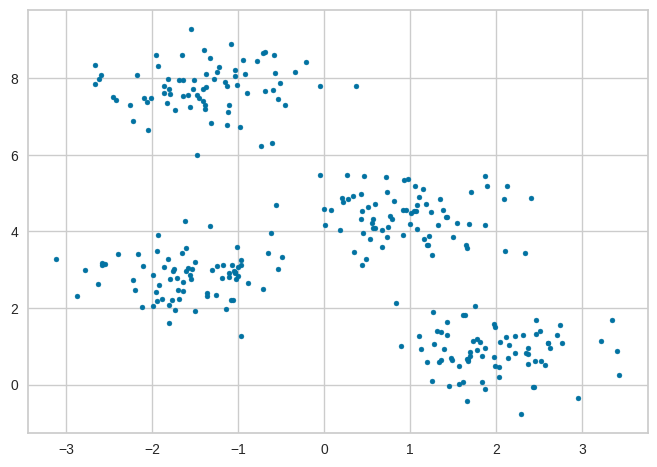

In [37]:
from sklearn.datasets import make_blobs

#Generamos un dataset sintético
x_ejemplo1, y_ejemplo1 = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(x_ejemplo1[:, 0], x_ejemplo1[:, 1], s=50,marker='.')
plt.show()

A priori, podemos ver fácilmente que estos datos se podrían separar en grupos <br>
Luego vamos a formalizar cómo hacer esto!


Para entrenar un cluster k-means, debemos importar KMeans del módulo `sklearn.cluster`.

Este algoritmo posee diferentes hiper-parámetros que se pueden configurar:

* `init`: es el método de inicialización de los centroides. En este caso definimos random para que se seleccionen aleatoriamente los puntos.

* `n_clusters`: definine la cantidad N de clústers que queremos como resultado.

* `random_state`: es la semilla de la aleatorización.

In [4]:
kmeans = KMeans(n_clusters=4)  #Creamos un objeto de la clase KMeans para realizar el agrupamiento

kmeans.fit(x_ejemplo1) #Entrenamos el algoritmo para que aprenda cómo agrupar

y_kmeans = kmeans.predict(x_ejemplo1)

In [5]:
y_kmeans

array([0, 1, 2, 1, 0, 0, 3, 2, 1, 1, 3, 1, 2, 1, 0, 2, 2, 0, 3, 3, 0, 0,
       2, 3, 3, 2, 0, 2, 3, 2, 1, 1, 2, 1, 1, 1, 1, 1, 3, 0, 2, 3, 2, 2,
       3, 3, 1, 3, 1, 0, 3, 0, 1, 0, 0, 3, 1, 3, 1, 0, 1, 2, 1, 3, 3, 3,
       1, 0, 1, 3, 2, 3, 1, 3, 3, 1, 3, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 2,
       1, 1, 2, 0, 1, 3, 3, 2, 0, 0, 2, 3, 1, 0, 1, 0, 2, 0, 0, 2, 1, 2,
       3, 3, 0, 1, 0, 2, 1, 0, 0, 2, 3, 0, 3, 0, 0, 0, 0, 3, 0, 3, 1, 3,
       3, 0, 1, 3, 3, 1, 2, 1, 1, 3, 2, 3, 2, 3, 1, 2, 1, 1, 1, 2, 1, 2,
       0, 3, 1, 3, 0, 2, 1, 2, 2, 0, 2, 3, 3, 2, 0, 2, 2, 1, 0, 2, 3, 1,
       0, 0, 2, 3, 0, 2, 3, 3, 2, 2, 2, 2, 0, 1, 2, 3, 2, 2, 3, 3, 3, 2,
       3, 1, 2, 3, 0, 3, 2, 1, 3, 1, 2, 1, 2, 3, 2, 2, 1, 3, 3, 0, 0, 2,
       1, 0, 0, 3, 0, 3, 2, 1, 1, 2, 2, 1, 2, 0, 3, 2, 0, 3, 1, 3, 0, 2,
       0, 1, 1, 1, 1, 3, 3, 1, 2, 3, 0, 2, 3, 3, 3, 0, 0, 1, 2, 2, 3, 0,
       1, 3, 2, 1, 2, 0, 0, 3, 3, 2, 0, 0, 0, 2, 1, 1, 0, 0, 2, 0, 0, 0,
       1, 3, 1, 2, 0, 0, 1, 1, 1, 0, 0, 2, 1, 3], d

Visualicemos los grupos y el centroide de cada uno

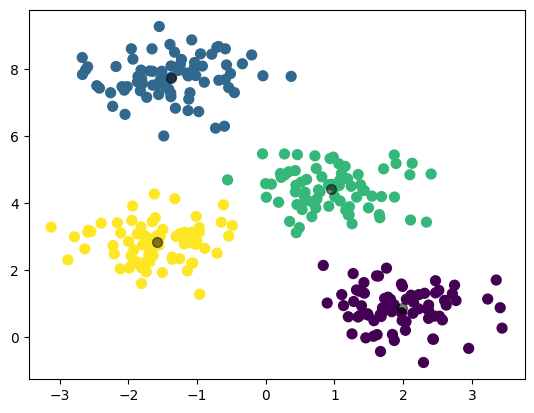

In [6]:
plt.scatter(x_ejemplo1[:, 0], x_ejemplo1[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5,marker='.')
plt.show()

Implementemos nuestro propio kmeans

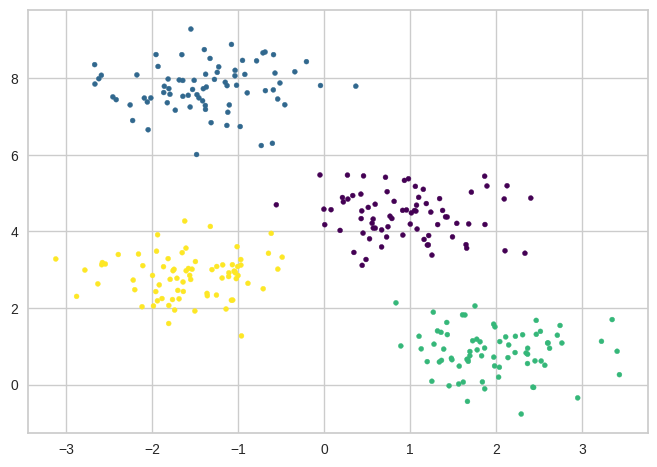

In [40]:
from sklearn.metrics import pairwise_distances_argmin

def nuestro_kmeans(X, n_clusters, rseed=2):
    # 1. Elegimos los grupos random
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centroides = X[i]

    cambien_centroides=True
    while cambien_centroides:
        # 2. Asignamos grupos en función de la distancia al centroide más cercano
        labels = pairwise_distances_argmin(X, centroides)

        # 3. Enconramos nuevos centroideas en función de la media de las observaciones en cada cluster
        nuevos_centroides = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 4. Verificamos si los centroides cambiaron con respecto a la iteración anterior
        if np.all(centroides == nuevos_centroides):
            cambien_centroides=False
        centroides = nuevos_centroides

    return centroides, labels

centroides, labels = nuestro_kmeans(x_ejemplo1, 4)
plt.scatter(x_ejemplo1[:, 0], x_ejemplo1[:, 1], c=labels,
            s=50, cmap='viridis',marker='.')
plt.show()

Este algoritmo tiene la particularidad de poder no llegar al mejor resultado. <br>
Como la inicialización es al azar, de cambiar la semilla de generación, los grupos formados podrían ser distintos

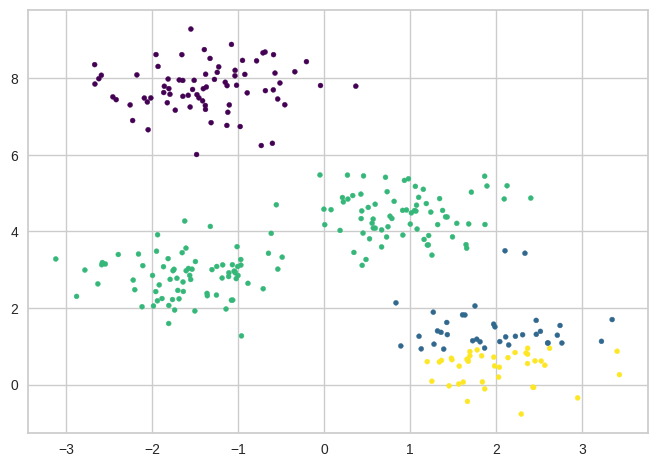

In [41]:
centers, labels = nuestro_kmeans(x_ejemplo1, 4, rseed=0)
plt.scatter(x_ejemplo1[:, 0], x_ejemplo1[:, 1], c=labels,
            s=50, cmap='viridis',marker='.')
plt.show()

La cantidad de grupos (clusters) deben ser definidos antes de ejecutar el método. <br>
Probemos que pasa si buscamos 6 clusters

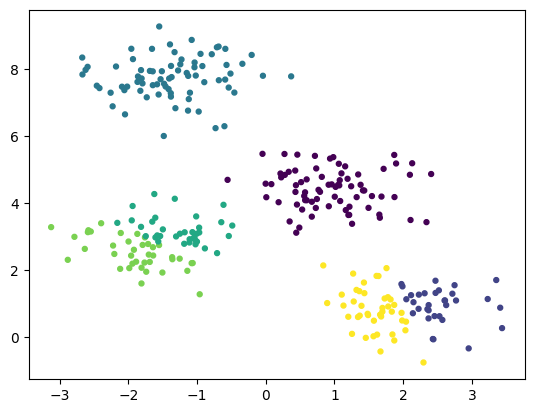

In [9]:
labels = KMeans(6, random_state=0).fit_predict(x_ejemplo1)
plt.scatter(x_ejemplo1[:, 0], x_ejemplo1[:, 1], c=labels,
            s=50, cmap='viridis',marker=".")
plt.show()

k-means tiende a conseguir fronteras circulares para los grupos
Esto puede ser un problema con formas más complicadas

Por ejemplo veamos el siguiente ejemplo

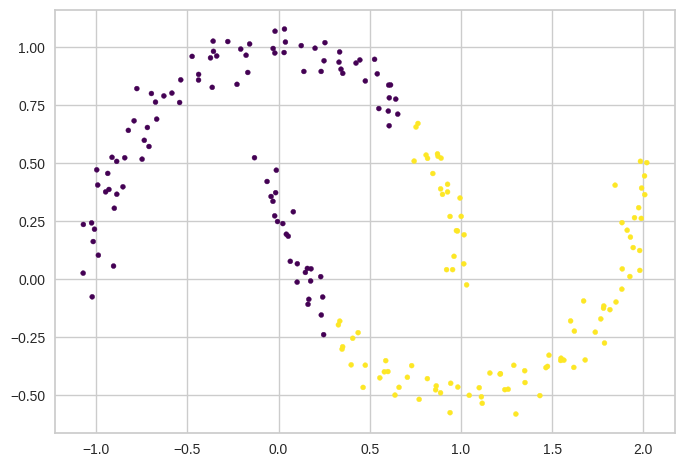

In [42]:
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

labels = KMeans(2, random_state=6).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis',marker='.')
plt.show()

Los métodos para formar grupos donde las observaciones forman geometrías complejas están fuera del alcance de este curso <br>
Si no controlas la ansiedad -> Cluster Spectral <br>
Sólo a modo de ejemplo veamos como quedarían los grupos

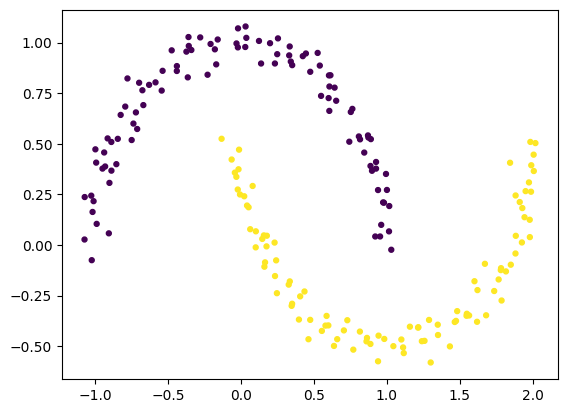

In [11]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,
            s=50, cmap='viridis',marker='.')
plt.show()

Cómo este método se basa en distancias, y las variables pueden tener distintas unidades, etc., y por lo tanto conviene standarizar <br>
Esto lo vamos a ver la clase se sigue, por ahora vamos a decir que este procedimiento se enfoca en cambiar las escalas para hacer las variables comparables

## Métricas de evaluación para Clustering

### ¿Cómo elegir el tamaño del Cluster?

Las métricas mas extendidas en clustering son el método de Elbow y el Índice de Silueta.

El **método del Codo** consiste en calcular la suma de los errores cuadráticos dentro de cada cluster (*Within-Cluster Sum of Squares*, WCSS) para diferentes valores de 𝑘. En K-Means, el “error” se entiende como la distancia de cada punto a su centroide asignado. A medida que se incrementa el número de clusters, el WCSS disminuye, pero llega un punto donde la mejora deja de ser significativa. Ese punto de inflexión, que gráficamente se asemeja a un 'codo', indica el número de clusters más adecuado.



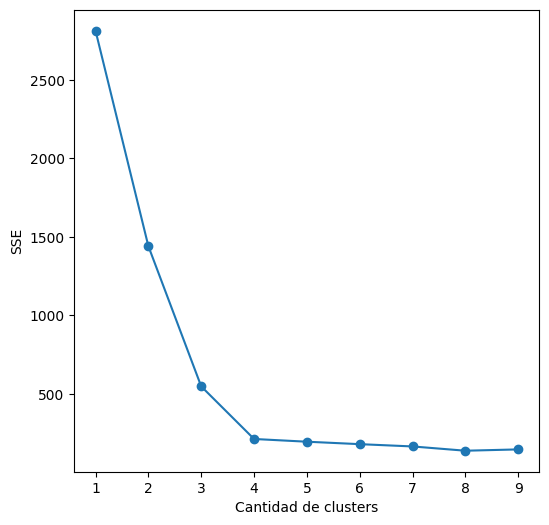

In [12]:
# Corro el algoritmo con K entre 2 y 10 y voy guardando el error para luego graficarlo.
sse = []
list_k = list(range(1, 10))

for k in list_k:
    km = KMeans(n_clusters=k)
    km.fit(x_ejemplo1)
    sse.append(km.inertia_)

# Grafico el SSE por K
plt.figure(figsize=(6, 6))
plt.plot(list_k, sse, '-o')
plt.xlabel(r'Cantidad de clusters')
plt.ylabel('SSE')
plt.show()

A medida que aumentamos el número de clústeres
𝑘, la inercia disminuye (esto es, la dispersión de los puntos alrededor de sus centroides), porque los clústeres se vuelven más pequeños y los datos ajustan mejor a su centroide. Sin embargo, llega un punto donde agregar más clústeres no reduce significativamente la inercia, lo que indica que ya no obtenemos una mejora sustancial en la agrupación.

Vemos que en 4 clusters la pendiente que se forma en el gráfico se quiebra, entonces vamos a probar utilizando este valor como cantidad de clusters

## Silhouette

El Índice de Silueta es una métrica que permite evaluar la calidad de un clustering al medir qué tan bien se separan los grupos entre sí.

Para cada observación, el valor de silueta compara:

* La **cohesión**: qué tan cerca está de los puntos de su propio cluster.

* La **separación**: qué tan lejos está de los puntos del cluster más próximo.

El índice oscila en el rango $[−1,1]$:

* Valores cercanos a 1 indican que los puntos están bien asignados a su cluster.

* Valores cercanos a 0 sugieren que los puntos están en el límite entre dos clusters.

* Valores negativos indican una posible asignación incorrecta.

Para cada punto $i$, el índice de silueta $s(i)$ se define como:

$$
s(i) = \frac{b(i) - a(i)}{\max \{a(i), b(i)\}}
$$

donde:
- $a(i)$: la distancia promedio de $i$ a todos los demás puntos de su mismo cluster (cohesión).
- $b(i)$: la distancia promedio de $i$ a todos los puntos del cluster más cercano distinto al suyo (separación).



A continuación graficamos el índice de silueta variando la cantidad de clusters entre 2 y 5.

In [13]:
from sklearn.metrics import silhouette_score

list_k = list(range(2, 6))

for n_clusters in list_k:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict(x_ejemplo1)

    score = silhouette_score (x_ejemplo1, preds)
    print ("For n_clusters =" + str(n_clusters) + " silhouette score is " + str(score))

For n_clusters =2 silhouette score is 0.4546802473065816
For n_clusters =3 silhouette score is 0.5890390393551768
For n_clusters =4 silhouette score is 0.6819938690643478
For n_clusters =5 silhouette score is 0.5794419498851084


El número óptimo de clusters es: 4


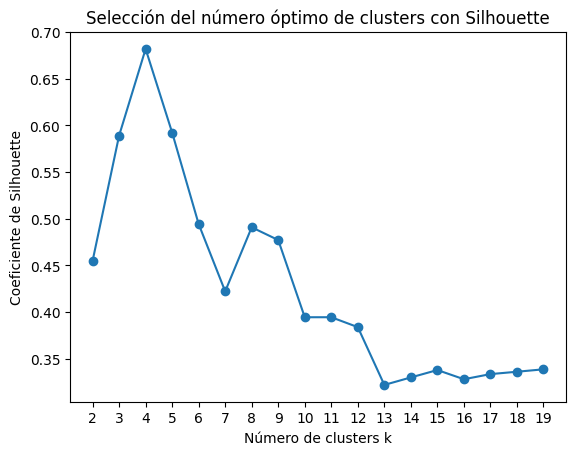

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Definir el rango de valores de k a probar
k_range = range(2, 20)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_ejemplo1)  # X es tu dataset
    score = silhouette_score(x_ejemplo1, labels)
    silhouette_scores.append(score)

# Encontrar el k con el mejor coeficiente de silhouette
optimal_k = k_range[np.argmax(silhouette_scores)]

print(f"El número óptimo de clusters es: {optimal_k}")

# Graficar los valores de silhouette para cada k
import matplotlib.pyplot as plt

plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Número de clusters k")
plt.ylabel("Coeficiente de Silhouette")
plt.title("Selección del número óptimo de clusters con Silhouette")
plt.xticks(np.arange(min(k_range), max(k_range)+1, 1))
plt.show()


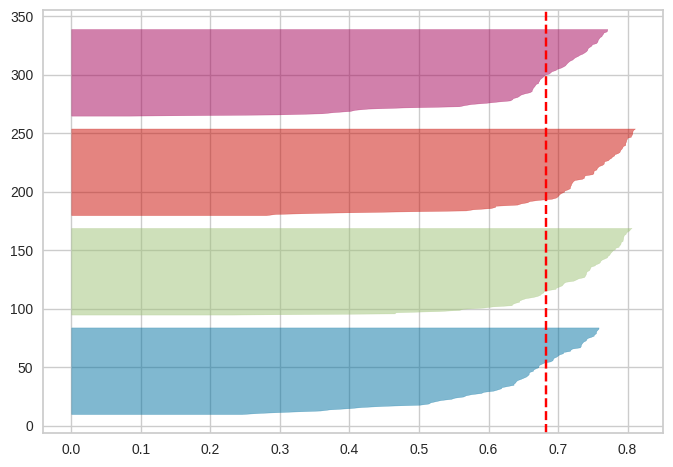

In [45]:
from yellowbrick.cluster import SilhouetteVisualizer

model = KMeans(4, random_state=0)

# Visualizamos el gráfico de silueta
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')    # Instancio el visualizador
visualizer.fit(x_ejemplo1)
plt.show()

Se observan 4 bandas bien definidas, lo que indica que el clustering logra separar los datos en grupos claros. Las bandas son relativamente anchas y uniformes, lo que sugiere que cada clúster tiene una cantidad razonable de puntos.

La mayoría de los valores de silhouette se encuentran por encima del valor promedio (la línea roja), lo que indica una buena separación entre los clusters. Un silhouette cercano a 1 significa que los puntos están bien agrupados dentro de su clúster y lejos de los demás.

## Hopkins: Tendencia al clustering

In [16]:
#from pyclustertend import hopkins

#hopkins(x_ejemplo1,x_ejemplo1.shape[0])

El estadístico de Hopkins es una técnica que permite evaluar si un conjunto de datos presenta una estructura de clústeres o si, por el contrario, está distribuido de manera aleatoria en el espacio.

Este método consiste en:  

1. Generar *m* puntos distribuidos al azar en el espacio muestral.  
2. Extraer *m* puntos reales del dataset.  
3. Calcular las distancias a los vecinos más cercanos en los datos reales dentro de:  
   - El subconjunto de datos generados al azar (*u*).  
   - El subconjunto de datos extraídos del dataset (*w*).  
4. Calcular el coeficiente de **Hopkins (H)** como:  


$H = \frac{\sum_i u_i}{\sum_i u_i + \sum_i w_i}$


<br>

**Interpretación del Estadístico de Hopkins**  
- Si los datos no presentan estructura de clústeres, entonces los puntos sintéticos y los reales tienen distribuciones similares (las distancias $w_i$ y $u_i$ serán más o menos del mismo orden). Entonces $ \sum u \approx \sum w $ y $H \approx 0.5 $, indicando que los datos no tienen una estructura de clústeres clara.  
- Si los datos sí forman clústeres, los puntos sintéticos tienden a caer lejos de los clústeres (mayores $u_i$). Dicho de otra forma, los puntos generados al azar están menos agrupados en comparación con los puntos reales, es decir, $ \sum u >> \sum w $. Entonces $ H >> 0.5 $, lo que sugiere que los datos presentan una estructura de clústeres y que el clustering es adecuado.  

**Reglas prácticas:**
- $ H > 0.75 $: fuerte evidencia de estructura de clústeres (los algoritmos de clustering son adecuados).
- $ H \approx 0.5 $: distribución aleatoria, sin clústeres definidos.
- $ H < 0.5 $: indica regularidad o repulsión entre los puntos (poco común en datasets reales).


In [17]:
from sklearn.neighbors import NearestNeighbors
import random

In [18]:
def Hopkins(datos,*args):
    n = datos.shape[0] # filas
    d = datos.shape[1] # columnas

    if not args:
        m = int(0.1 * n) # cantidad de puntos al azar (default)
        print("Numero de puntos al azar por defecto",m)
    else:
        m = args[0] # cantidad de puntos al azar

    nbrs = NearestNeighbors(n_neighbors=1, algorithm='brute').fit(datos) # buscador de vecinos
    #random.seed(42)
    rand_ind = random.sample(range(0, n, 1), m) # indices al azar

    ui = []
    wi = []
    for j in range(0, m):

        u_dist, _ = nbrs.kneighbors(np.random.normal(size=(1, d)).reshape(1, -1), 2,
                                    return_distance=True) # distancia a los nuevos puntos

        ui.append(u_dist[0][1])

        w_dist, _ = nbrs.kneighbors(datos[rand_ind[j]].reshape(1, -1), 2, return_distance=True) # distancia a los puntos al azar
        #w_dist, _ = nbrs.kneighbors(datos.iloc[rand_ind[j]].values.reshape(1, -1), 2, return_distance=True) # distancia a los puntos al azar si df es un dataframe

        wi.append(w_dist[0][1])


    H = sum(ui) / (sum(ui) + sum(wi))
    return H

In [19]:
Hopkins(x_ejemplo1)

Numero de puntos al azar por defecto 30


np.float64(0.9280959170847574)

* Un valor de Hopkins cercano a 1 (por ejemplo, 0.9) sugiere que los datos están estructurados y probablemente sean adecuados para la agrupación en clústeres.


In [20]:
# Escalar Features -- Lo vamos a ver las próximas clases
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [21]:
#Escalamos todos los features para que los valores esten un mismo rango y no afecte la escala
x_ejemplo1_escalado=scaler.fit_transform(x_ejemplo1)

In [22]:
Hopkins(x_ejemplo1_escalado)

Numero de puntos al azar por defecto 30


np.float64(0.9840029888100407)

#### Validación externa

Se cuenta con labels previos a la utilización de kmeans, y se los compara con los grupos que se armaron en kmeans

## Ejemplo 1

In [23]:
from sklearn.datasets import load_iris

In [24]:
iris = load_iris()
nombres_columnas = [ x.replace('(cm)','').rstrip().replace(" ","_") for x in iris['feature_names']]
df_iris = pd.DataFrame(iris['data'],columns=nombres_columnas)

y_iris=iris['target']

In [25]:
from sklearn.preprocessing import scale, MinMaxScaler

scaler = MinMaxScaler()
df_iris_escalado = scaler.fit_transform(df_iris)

In [26]:
kmeans = KMeans(3, random_state=0)

kmeans.fit(df_iris) # fitear con iris df_iris_escalado

KMeans(n_clusters=3, random_state=0)

In [27]:
clusters=kmeans.predict(df_iris)
print(clusters)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [28]:
validacion_externa=pd.DataFrame(zip(y_iris,clusters),columns=['labels_reales','clusters'])
validacion_externa.head()

,labels_reales,clusters
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [29]:
pd.crosstab(validacion_externa.labels_reales,
            validacion_externa.clusters)

clusters,0,1,2
labels_reales,,,
0,0,50,0
1,47,0,3
2,14,0,36


## Ejemplo 2

Apliquemos kmeans a compresión de imágenes
<br>  
Supongamos que tenemos una imagen con una cantidad de muy grande de colores (millones) y la queremos representar con menos.<br>
<br>
Pasos a seguir:
* Pensemos la imagen como un dataset considerando a cada pixel como una fila (una observación) <br>
* Apliquemos kmeans a los pixels, lo que generará que pixeles con colores similares estén en el mismo cluster <br>
* Luego reemplacemos cada pixel por el valor del centroide del cluster al cual pertenece

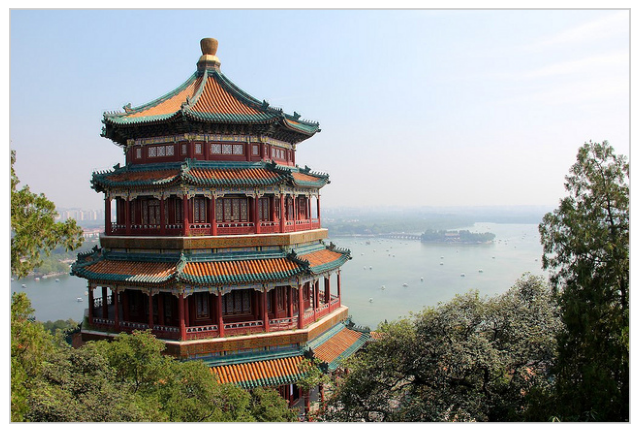

In [30]:
from sklearn.datasets import load_sample_image

imagen_original = load_sample_image("china.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(imagen_original)
plt.show()

In [31]:
imagen_original.shape

(427, 640, 3)

Representemos cada color como un número entre 0 y 1

In [32]:
data = imagen_original / 255.0 # use 0...1 scale
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

Utilicemos 16 colores para representar la imagen

In [33]:
K = 16
kmeans = KMeans(K, random_state=0)
kmeans.fit(data)
imagen_nuevos_colores = kmeans.cluster_centers_[kmeans.predict(data)]

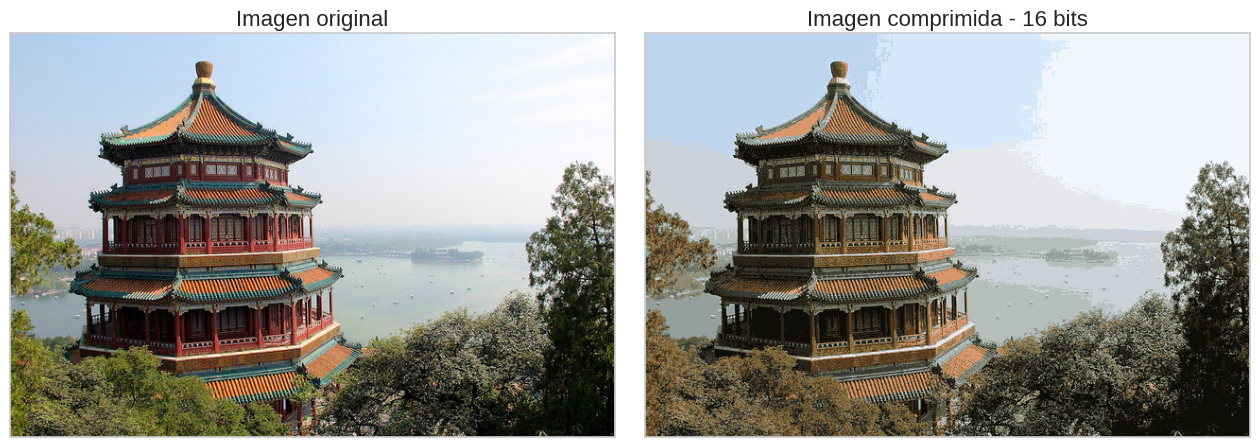

In [34]:
imagen_comprimida = imagen_nuevos_colores.reshape(imagen_original.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))

fig.subplots_adjust(wspace=0.05)
ax[0].imshow(imagen_original)
ax[0].set_title('Imagen original', size=16)
ax[1].imshow(imagen_comprimida)
ax[1].set_title(f'Imagen comprimida - {K} bits', size=16)
plt.show()